# 1. Common Pre Processing steps

- Read data
- Descriptive statistics
- Drop unnecessary columns (P.S. 5 columns need to be dropped).
- Check missing values
- Create new data for given models

-- For KNN model -> data_knn = data.copy() 

-- For Logistic Regression model -> data_lr = data.copy()

-- For Catboost model (categoric features stays untransformed) -> data_cb_cat = data.copy()

-- For XGBoost, LGBM, Catboost and Random Forest models -> data_xgb_lgbm_cb_rf = data.copy()


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


In [2]:
data = pd.read_excel(r"fraud_data.xlsx")
data.head()


,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud
0,PAYMENT,Indonesia,9839.64,C1231006815,170136.0,160296.36,M1979787155,9,0,Current,3/1/2018,Morning,0
1,PAYMENT,India,1864.28,C1666544295,21249.0,19384.72,M2044282225,10,0,Savings,5/1/2018,Morning,0
2,TRANSFER,India,181.00,C1305486145,181.0,0.00,C553264065,2,0,Current,7/1/2018,Morning,1
3,CASH_OUT,Australia,181.00,C840083671,181.0,0.00,C38997010,1,0,Current,6/1/2018,Afternoon,1
4,PAYMENT,Australia,11668.14,C2048537720,41554.0,29885.86,M1230701703,17,0,Current,6/1/2018,Morning,0


In [3]:
data.shape


(10125, 13)

## Descriptive stats


In [4]:
pd.set_option('display.max_columns', None)
data.describe(include='all')


,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud
count,10125,10125,1.012500e+04,10125,1.012500e+04,1.012500e+04,10125,10125.000000,10125.0,10125,10125,10125,10125.000000
unique,5,135,NaN,10119,NaN,NaN,6494,NaN,NaN,2,14,3,NaN
top,PAYMENT,Estados Unidos,NaN,C10001825,NaN,NaN,C985934102,NaN,NaN,Savings,6/1/2018,Afternoon,NaN
freq,5544,1282,NaN,7,NaN,NaN,68,NaN,NaN,6995,1453,3628,NaN
mean,NaN,NaN,1.048873e+05,NaN,8.836949e+05,9.046314e+05,NaN,10.513580,0.0,NaN,NaN,NaN,0.011654
std,NaN,NaN,2.706366e+05,NaN,2.124555e+06,2.170130e+06,NaN,5.809393,0.0,NaN,NaN,NaN,0.107330
min,NaN,NaN,2.390000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000,0.0,NaN,NaN,NaN,0.000000
25%,NaN,NaN,4.397580e+03,NaN,1.290000e+02,0.000000e+00,NaN,6.000000,0.0,NaN,NaN,NaN,0.000000
50%,NaN,NaN,1.279882e+04,NaN,2.136300e+04,1.019179e+04,NaN,10.000000,0.0,NaN,NaN,NaN,0.000000
75%,NaN,NaN,1.143818e+05,NaN,1.724320e+05,1.707442e+05,NaN,16.000000,0.0,NaN,NaN,NaN,0.000000


## Drop unnecessary columns


In [5]:
# 5 columns dropped, same logic as the reference notebook (drop ID-like /
# zero-information columns before modeling):
# - nameOrig, nameDest : near-unique transaction account identifiers
#                        (10119 / 6494 distinct values out of 10125 rows) -> no
#                        generalizable signal, behave like an ID/Name/SSN column
# - isFlaggedFraud     : constant column (a single value across all 10125 rows)
#                        -> zero variance, carries no information
# - Date of transaction: raw date string, not directly usable by the models and
#                        largely redundant with the 'Time of day' feature
# - branch             : very high-cardinality categorical (135 distinct
#                        countries) -> too sparse to encode reliably
for i in data[['nameOrig', 'nameDest', 'isFlaggedFraud', 'Date of transaction', 'branch']]:
    data.drop(i, axis=1, inplace=True)

data.columns


Index(['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'unusuallogin',
       'Acct type', 'Time of day', 'isFraud'],
      dtype='str')

## Missing Value check


In [6]:
data.isnull().sum()


type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
unusuallogin      0
Acct type         0
Time of day       0
isFraud           0
dtype: int64

In [7]:
data.select_dtypes(include='object').columns


/tmp/ipykernel_87/1181700076.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include='object').columns


Index(['type', 'Acct type', 'Time of day'], dtype='str')

## Create per-model copies


In [8]:
data_knn = data.copy()
data_lr = data.copy()
data_cb_cat = data.copy()
data_xgb_lgbm_cb_rf = data.copy()


# 2. Train Test split

- Declare inputs and target from the data for all models as below:

-- inputs_knn, inputs_lr, inputs_cb_cat, inputs_xgb_lgbm_cb_rf (inputs from xgb, lgbm, catboost and random forest has common preprocessing steps hence describe as one variable)

- Do Train Test Split for all 4 given inputs.

In [9]:
inputs_knn = data_knn.drop('isFraud', axis=1)
inputs_lr = data_lr.drop('isFraud', axis=1)
inputs_cb_cat = data_cb_cat.drop('isFraud', axis=1)
inputs_xgb_lgbm_cb_rf = data_xgb_lgbm_cb_rf.drop('isFraud', axis=1)
target = data['isFraud']

for i in inputs_cb_cat.select_dtypes(include='object').columns:
    inputs_cb_cat[i] = inputs_cb_cat[i].fillna('Missing Value')

X_train_knn, X_test_knn, y_train, y_test = train_test_split(inputs_knn, target, test_size=0.2, random_state=42)
X_train_lr, X_test_lr, y_train, y_test = train_test_split(inputs_lr, target, test_size=0.2, random_state=42)
X_train_cat, X_test_cat, y_train, y_test = train_test_split(inputs_cb_cat, target, test_size=0.2, random_state=42)
X_train_xgb_lgbm_cb_rf, X_test_xgb_lgbm_cb_rf, y_train, y_test = train_test_split(inputs_xgb_lgbm_cb_rf, target, test_size=0.2, random_state=42)

print('X_train shape KNN', X_train_knn.shape)
print('X_train shape LR', X_train_lr.shape)
print('X_train shape Catboost categorical', X_train_cat.shape)
print('X_train shape others ', X_train_xgb_lgbm_cb_rf.shape)
print('X_test shape KNN', X_test_knn.shape)
print('X_test shape LR', X_test_lr.shape)
print('X_test shape Catboost categorical', X_test_cat.shape)
print('X_test shape others', X_test_xgb_lgbm_cb_rf.shape)
print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)


X_train shape KNN (8100, 7)
X_train shape LR (8100, 7)
X_train shape Catboost categorical (8100, 7)
X_train shape others  (8100, 7)
X_test shape KNN (2025, 7)
X_test shape LR (2025, 7)
X_test shape Catboost categorical (2025, 7)
X_test shape others (2025, 7)
y_train shape (8100,)
y_test shape (2025,)


/tmp/ipykernel_87/2387186360.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in inputs_cb_cat.select_dtypes(include='object').columns:


# 3. Logistic Regression Preprocessing steps

- WoE transformation 
- Intercorrelation ( threshold 70% )
- Keep only columns ending with _woe inside X_train_fin_lr and X_test_fin_lr variables 

In [10]:
# Manual WoE transformation. Bin edges / category WoE values are always learned
# on the TRAIN split only, then applied to both train and test (no leakage).

def compute_woe_numeric(train_col, train_target, bins=5):
    _, bin_edges = pd.qcut(train_col, q=bins, duplicates='drop', retbins=True)
    bin_edges = list(bin_edges)
    bin_edges[0], bin_edges[-1] = -np.inf, np.inf          # cover values outside the train range
    binned = pd.cut(train_col, bins=bin_edges, include_lowest=True)
    stats = pd.DataFrame({'bin': binned, 'target': train_target}).groupby('bin', observed=True)['target'].agg(['count', 'sum'])
    stats.columns = ['total', 'bad']
    stats['good'] = stats['total'] - stats['bad']
    stats['dist_good'] = stats['good'].replace(0, 0.5) / stats['good'].sum()
    stats['dist_bad'] = stats['bad'].replace(0, 0.5) / stats['bad'].sum()
    stats['woe'] = np.log(stats['dist_good'] / stats['dist_bad'])
    return bin_edges, stats['woe']

def apply_woe_numeric(col, bin_edges, woe_map):
    return pd.cut(col, bins=bin_edges, include_lowest=True).map(woe_map)

def compute_woe_categorical(train_col, train_target):
    stats = pd.DataFrame({'cat': train_col.astype(str), 'target': train_target}).groupby('cat')['target'].agg(['count', 'sum'])
    stats.columns = ['total', 'bad']
    stats['good'] = stats['total'] - stats['bad']
    stats['dist_good'] = stats['good'].replace(0, 0.5) / stats['good'].sum()
    stats['dist_bad'] = stats['bad'].replace(0, 0.5) / stats['bad'].sum()
    stats['woe'] = np.log(stats['dist_good'] / stats['dist_bad'])
    return stats['woe']

def apply_woe_categorical(col, woe_map):
    return col.astype(str).map(woe_map).fillna(0)          # unseen category -> neutral WoE

numeric_cols_lr = X_train_lr.select_dtypes(include=np.number).columns.tolist()
categorical_cols_lr = X_train_lr.select_dtypes(include='object').columns.tolist()

for col in numeric_cols_lr:
    edges, woe_map = compute_woe_numeric(X_train_lr[col], y_train)
    X_train_lr[col + '_woe'] = apply_woe_numeric(X_train_lr[col], edges, woe_map)
    X_test_lr[col + '_woe'] = apply_woe_numeric(X_test_lr[col], edges, woe_map)

for col in categorical_cols_lr:
    woe_map = compute_woe_categorical(X_train_lr[col], y_train)
    X_train_lr[col + '_woe'] = apply_woe_categorical(X_train_lr[col], woe_map)
    X_test_lr[col + '_woe'] = apply_woe_categorical(X_test_lr[col], woe_map)

woe_cols = [c for c in X_train_lr.columns if c.endswith('_woe')]
X_train_lr[woe_cols].head()


/tmp/ipykernel_87/2558179151.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_lr = X_train_lr.select_dtypes(include='object').columns.tolist()


,amount_woe,oldbalanceOrg_woe,newbalanceOrig_woe,unusuallogin_woe,type_woe,Acct type_woe,Time of day_woe
9918,-0.041322,0.393827,-0.333179,0.432321,-1.093076,0.004035,-0.148613
9234,0.882441,0.393827,-0.333179,0.432321,1.070627,-0.008935,-0.148613
5814,-0.041322,0.393827,-0.333179,-0.691334,-1.201718,-0.008935,0.121914
792,-0.041322,0.393827,-0.333179,0.118308,-1.201718,0.004035,0.121914
1791,0.882441,0.249480,1.866367,0.432321,1.070627,0.004035,0.043604


In [11]:
# Intercorrelation (threshold 70%) among the WoE features
corr_matrix = X_train_lr[woe_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.7)]

print('WoE columns dropped for intercorrelation (>70%):', to_drop)
corr_matrix


WoE columns dropped for intercorrelation (>70%): []


,amount_woe,oldbalanceOrg_woe,newbalanceOrig_woe,unusuallogin_woe,type_woe,Acct type_woe,Time of day_woe
amount_woe,1.000000,0.019536,0.106763,0.018336,0.372446,0.007269,0.009669
oldbalanceOrg_woe,0.019536,1.000000,0.042211,0.029728,0.169710,0.000848,0.001939
newbalanceOrig_woe,0.106763,0.042211,1.000000,0.003425,0.273055,0.018493,0.007902
unusuallogin_woe,0.018336,0.029728,0.003425,1.000000,0.032098,0.001380,0.008096
type_woe,0.372446,0.169710,0.273055,0.032098,1.000000,0.019016,0.015261
Acct type_woe,0.007269,0.000848,0.018493,0.001380,0.019016,1.000000,0.020023
Time of day_woe,0.009669,0.001939,0.007902,0.008096,0.015261,0.020023,1.000000


In [12]:
# Keep only the surviving _woe columns
woe_cols_final = [c for c in woe_cols if c not in to_drop]

X_train_fin_lr = X_train_lr[woe_cols_final]
X_test_fin_lr = X_test_lr[woe_cols_final]

X_train_fin_lr.shape, X_test_fin_lr.shape


((8100, 7), (2025, 7))

# 4. KNN Preprocessing steps

- Outlier Treatment
- Intercorrelation ( threshold 70% )
- VIF (1-5)
- Keep only numeric columns which survived after VIF and categoric columns
- Conversion (One Hot Encoder)
- Scale the data (X_train_scaled, X_test_scaled)


In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols_knn = X_train_knn.select_dtypes(include=np.number).columns.tolist()
categorical_cols_knn = X_train_knn.select_dtypes(include='object').columns.tolist()

# Outlier treatment: IQR capping, bounds learned on the train split only
for col in numeric_cols_knn:
    Q1 = X_train_knn[col].quantile(0.25)
    Q3 = X_train_knn[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    X_train_knn[col] = X_train_knn[col].clip(lower, upper)
    X_test_knn[col] = X_test_knn[col].clip(lower, upper)

X_train_knn[numeric_cols_knn].describe()


/tmp/ipykernel_87/2460765881.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_knn = X_train_knn.select_dtypes(include='object').columns.tolist()


,amount,oldbalanceOrg,newbalanceOrig,unusuallogin
count,8100.000000,8100.000000,8100.000000,8100.000000
mean,70545.015898,125721.010739,122616.738236,10.529630
std,97288.125485,182252.126504,186238.644906,5.802953
min,3.750000,0.000000,0.000000,0.000000
25%,4474.100000,129.750000,0.000000,6.000000
50%,13020.465000,21567.000000,10590.785000,11.000000
75%,115214.802500,185146.500000,186555.007500,16.000000
max,281325.856250,462671.625000,466387.518750,20.000000


In [14]:
# Intercorrelation ( threshold 70% )
corr_matrix_knn = X_train_knn[numeric_cols_knn].corr().abs()
upper_knn = corr_matrix_knn.where(np.triu(np.ones(corr_matrix_knn.shape), k=1).astype(bool))
to_drop_knn_corr = [col for col in upper_knn.columns if any(upper_knn[col] > 0.7)]

print('Numeric columns dropped for intercorrelation (>70%):', to_drop_knn_corr)
numeric_cols_knn = [c for c in numeric_cols_knn if c not in to_drop_knn_corr]
numeric_cols_knn


Numeric columns dropped for intercorrelation (>70%): ['newbalanceOrig']


['amount', 'oldbalanceOrg', 'unusuallogin']

In [15]:
# VIF (1-5): iteratively drop the highest-VIF feature until all remaining <= 5
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data['feature'] = df.columns
    vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

vif_features = numeric_cols_knn.copy()
while True:
    vif_df = calculate_vif(X_train_knn[vif_features].dropna())
    max_vif = vif_df['VIF'].max()
    if max_vif > 5 and len(vif_features) > 1:
        drop_feat = vif_df.sort_values('VIF', ascending=False).iloc[0]['feature']
        vif_features.remove(drop_feat)
    else:
        break

vif_df


,feature,VIF
0,amount,1.086227
1,oldbalanceOrg,1.086150
2,unusuallogin,1.000487


In [16]:
# Keep only numeric columns that survived VIF + the categoric columns
X_train_knn_selected = X_train_knn[vif_features + categorical_cols_knn]
X_test_knn_selected = X_test_knn[vif_features + categorical_cols_knn]

X_train_knn_selected.head()


,amount,oldbalanceOrg,unusuallogin,type,Acct type,Time of day
9918,198823.60000,9448.47,15,CASH_OUT,Savings,Night
9234,4018.89000,3021.00,16,PAYMENT,Current,Night
5814,281325.85625,230.02,2,TRANSFER,Current,Morning
792,281325.85625,0.00,10,TRANSFER,Savings,Morning
1791,3559.49000,69159.81,16,PAYMENT,Savings,Afternoon


In [17]:
# Conversion (One Hot Encoder)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_ohe = ohe.fit_transform(X_train_knn_selected[categorical_cols_knn])
X_test_cat_ohe = ohe.transform(X_test_knn_selected[categorical_cols_knn])
ohe_cols = ohe.get_feature_names_out(categorical_cols_knn)

X_train_knn_ohe = pd.concat([
    X_train_knn_selected[vif_features].reset_index(drop=True),
    pd.DataFrame(X_train_cat_ohe, columns=ohe_cols)
], axis=1)

X_test_knn_ohe = pd.concat([
    X_test_knn_selected[vif_features].reset_index(drop=True),
    pd.DataFrame(X_test_cat_ohe, columns=ohe_cols)
], axis=1)

X_train_knn_ohe.head()


,amount,oldbalanceOrg,unusuallogin,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,Acct type_Current,Acct type_Savings,Time of day_Afternoon,Time of day_Morning,Time of day_Night
0,198823.60000,9448.47,15,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,4018.89000,3021.00,16,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,281325.85625,230.02,2,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,281325.85625,0.00,10,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,3559.49000,69159.81,16,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [18]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_knn_ohe), columns=X_train_knn_ohe.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_knn_ohe), columns=X_test_knn_ohe.columns)

X_train_scaled.shape, X_test_scaled.shape


((8100, 13), (2025, 13))

# 5. XGBoost, Catboost, LightGBM and Random Forest pre processing

- Conversion (Label Encoder)

In [19]:
new_data = data.copy()

from sklearn.preprocessing import LabelEncoder

encoders = {}
for i in X_train_xgb_lgbm_cb_rf.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train_xgb_lgbm_cb_rf[i] = le.fit_transform(X_train_xgb_lgbm_cb_rf[i])
    encoders[i] = le

X_train_xgb_lgbm_cb_rf


/tmp/ipykernel_87/3364377104.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in X_train_xgb_lgbm_cb_rf.select_dtypes(include=['object']).columns:


,type,amount,oldbalanceOrg,newbalanceOrig,unusuallogin,Acct type,Time of day
9918,1,198823.60,9448.47,0.00,15,1,2
9234,3,4018.89,3021.00,0.00,16,0,2
5814,4,436099.98,230.02,0.00,2,0,1
792,4,637161.00,0.00,0.00,10,1,1
1791,3,3559.49,69159.81,65600.32,16,1,0
...,...,...,...,...,...,...,...
5734,4,130145.62,14281.00,0.00,1,1,0
5191,3,1808.31,29927.00,28118.69,10,1,0
5390,3,1288.03,1086.00,0.00,9,1,2
860,1,171757.76,0.00,0.00,9,1,0


In [20]:
for i in encoders:
    le = encoders[i]
    X_test_xgb_lgbm_cb_rf[i] = le.transform(X_test_xgb_lgbm_cb_rf[i])

X_test_xgb_lgbm_cb_rf


,type,amount,oldbalanceOrg,newbalanceOrig,unusuallogin,Acct type,Time of day
3781,3,2789.37,96.00,0.00,17,1,2
2922,0,38978.32,6269058.27,6308036.58,8,1,0
5070,0,131815.57,1135018.52,1266834.10,15,1,2
7246,0,193558.01,4975414.18,5168972.19,10,1,2
623,0,219220.21,4028495.42,4247715.63,6,0,0
...,...,...,...,...,...,...,...
9866,3,5306.87,72298.00,66991.13,10,1,0
1937,3,11488.23,20243.00,8754.77,15,1,0
4705,1,33881.81,19486.34,0.00,18,1,0
8547,3,10024.27,0.00,0.00,3,0,1


# 6. Train and evaluate all models together

- Import train_and_evaluate_model() function

In [21]:
from sklearn.metrics import confusion_matrix, classification_report

def train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    try:
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_prob_train = model.predict_proba(X_train)[:, 1]

        roc_prob_train = roc_auc_score(y_train, y_prob_train)
        gini_prob_train = roc_prob_train * 2 - 1
        confusion_matrix_result_train = confusion_matrix(y_train, y_pred_train)
        classification_report_result_train = classification_report(y_train, y_pred_train)

        print(f'Model Performance for {model_name}')
        print('Train Gini prob is', gini_prob_train * 100)
        print(classification_report_result_train)
        print(confusion_matrix_result_train)

        y_pred_test = model.predict(X_test)
        y_prob_test = model.predict_proba(X_test)[:, 1]

        roc_prob_test = roc_auc_score(y_test, y_prob_test)
        gini_prob_test = roc_prob_test * 2 - 1
        confusion_matrix_result_test = confusion_matrix(y_test, y_pred_test)
        classification_report_result_test = classification_report(y_test, y_pred_test)

        print(f'Model Performance for {model_name}')
        print('Test Gini prob is', gini_prob_test * 100)
        print(classification_report_result_test)
        print(confusion_matrix_result_test)

        return [gini_prob_train, gini_prob_test]

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


# 7. Modeling

- Create a list and add models below:
1. LogisticRegression()
2. KNeighborsClassifier()
3. RandomForestClassifier()
4. XGBoostClassifier()
5. LGBMClassifier()
6. CatBoostClassifier()
7. CatBoostClassifier(cat_features)

- Use the train_and_evaluate_model function to evaluate all specified models.
- Handle model-specific X_train and X_test inputs using if/elif conditions for LogisticRegression(), KNeighborsClassifier(), and CatBoostClassifier(cat_features).


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [23]:
models = []

lr_model_def = LogisticRegression(random_state=42, max_iter=1000)
knn_model_def = KNeighborsClassifier()
rf_model_def = RandomForestClassifier(random_state=42)
xgb_model_def = XGBClassifier(random_state=42)
lgb_model_def = LGBMClassifier(random_state=42, verbose=-1)
catboost_model_def = CatBoostClassifier(random_state=42, verbose=0)

categorical_columns = inputs_cb_cat.select_dtypes(include='object').columns.tolist()
catboost_model_custom = CatBoostClassifier(cat_features=categorical_columns, random_state=42, verbose=0)

models.extend([
    ('LogisticRegression', lr_model_def),
    ('KNN', knn_model_def),
    ('RandomForest', rf_model_def),
    ('XGBoost', xgb_model_def),
    ('LightGBM', lgb_model_def),
    ('CatBoost', catboost_model_def),
    ('CatBoost_Custom', catboost_model_custom)
])

models


/tmp/ipykernel_87/135866462.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = inputs_cb_cat.select_dtypes(include='object').columns.tolist()


[('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42)),
 ('KNN', KNeighborsClassifier()),
 ('RandomForest', RandomForestClassifier(random_state=42)),
 ('XGBoost',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...)),
 ('LightGBM', LGBMClassifier(ran

In [24]:
gini_df = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models:
    if model_name == 'LogisticRegression':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_fin_lr, y_train, X_test_fin_lr, y_test)
    elif model_name == 'KNN':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    elif model_name == 'CatBoost_Custom':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_cat, y_train, X_test_cat, y_test)
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train_xgb_lgbm_cb_rf, y_train, X_test_xgb_lgbm_cb_rf, y_test)

    if gini_prob is not None:
        gini_df = pd.concat([gini_df, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted = gini_df.sort_values(by='Test Gini', ascending=False)

gini_df_sorted


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

Model Performance for LogisticRegression
Train Gini prob is 61.3533077211394
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8004
           1       0.00      0.00      0.00        96

    accuracy                           0.99      8100
   macro avg       0.49      0.50      0.50      8100
weighted avg       0.98      0.99      0.98      8100

[[8004    0]
 [  96    0]]
Model Performance for LogisticRegression
Test Gini prob is 43.273725774973926
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2003
           1       0.00      0.00      0.00        22

    accuracy                           0.99      2025
   macro avg       0.49      0.50      0.50      2025
weighted avg       0.98      0.99      0.98      2025

[[2003    0]
 [  22    0]]


Model Performance for KNN
Train Gini prob is 97.12747792770283
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8004
           1       0.82      0.09      0.17        96

    accuracy                           0.99      8100
   macro avg       0.90      0.55      0.58      8100
weighted avg       0.99      0.99      0.98      8100

[[8002    2]
 [  87    9]]
Model Performance for KNN
Test Gini prob is 14.108382880225111
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2003
           1       0.50      0.05      0.08        22

    accuracy                           0.99      2025
   macro avg       0.74      0.52      0.54      2025
weighted avg       0.98      0.99      0.98      2025

[[2002    1]
 [  21    1]]


Model Performance for RandomForest
Train Gini prob is 100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8004
           1       1.00      1.00      1.00        96

    accuracy                           1.00      8100
   macro avg       1.00      1.00      1.00      8100
weighted avg       1.00      1.00      1.00      8100

[[8004    0]
 [   0   96]]
Model Performance for RandomForest
Test Gini prob is 65.87391639813008
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2003
           1       0.50      0.05      0.08        22

    accuracy                           0.99      2025
   macro avg       0.74      0.52      0.54      2025
weighted avg       0.98      0.99      0.98      2025

[[2002    1]
 [  21    1]]
Model Performance for XGBoost
Train Gini prob is 100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      80

Model Performance for LightGBM
Train Gini prob is 100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8004
           1       1.00      1.00      1.00        96

    accuracy                           1.00      8100
   macro avg       1.00      1.00      1.00      8100
weighted avg       1.00      1.00      1.00      8100

[[8004    0]
 [   0   96]]
Model Performance for LightGBM
Test Gini prob is 60.32995960604548
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2003
           1       0.82      0.41      0.55        22

    accuracy                           0.99      2025
   macro avg       0.91      0.70      0.77      2025
weighted avg       0.99      0.99      0.99      2025

[[2001    2]
 [  13    9]]


Model Performance for CatBoost
Train Gini prob is 99.11554639346993
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8004
           1       1.00      0.56      0.72        96

    accuracy                           0.99      8100
   macro avg       1.00      0.78      0.86      8100
weighted avg       0.99      0.99      0.99      8100

[[8004    0]
 [  42   54]]
Model Performance for CatBoost
Test Gini prob is 55.194481005764075
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2003
           1       0.86      0.27      0.41        22

    accuracy                           0.99      2025
   macro avg       0.92      0.64      0.70      2025
weighted avg       0.99      0.99      0.99      2025

[[2002    1]
 [  16    6]]


Model Performance for CatBoost_Custom
Train Gini prob is 96.27738214226218
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8004
           1       0.96      0.51      0.67        96

    accuracy                           0.99      8100
   macro avg       0.98      0.76      0.83      8100
weighted avg       0.99      0.99      0.99      8100

[[8002    2]
 [  47   49]]
Model Performance for CatBoost_Custom
Test Gini prob is 59.996369082739534
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2003
           1       1.00      0.41      0.58        22

    accuracy                           0.99      2025
   macro avg       1.00      0.70      0.79      2025
weighted avg       0.99      0.99      0.99      2025

[[2003    0]
 [  13    9]]


,Model,Train Gini,Test Gini
2,RandomForest,1.0,0.658739
4,LightGBM,1.0,0.6033
6,CatBoost_Custom,0.962774,0.599964
5,CatBoost,0.991155,0.551945
3,XGBoost,1.0,0.493101
0,LogisticRegression,0.613533,0.432737
1,KNN,0.971275,0.141084


# 8. Hyperparameter Optimization with Optuna

- Optimize parameters of models ( KNeighborsClassifier(), RandomForestClassifier(), XGBoostClassifier(), LGBMClassifier(), CatBoostClassifier() )  using Optuna
- Call train_and_evaluate_model function to see results of optimized model

In [25]:
from sklearn.model_selection import cross_val_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [26]:
def best_params_for_knn(trial):
    param = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 30),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_int('p', 1, 2)
    }

    knn_clf = KNeighborsClassifier(**param)
    auc = cross_val_score(knn_clf, X_train_scaled, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(best_params_for_knn, n_trials=15)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_knn_model = KNeighborsClassifier(**best_params)


Best trial:
  Value: 0.742
  Params:  {'n_neighbors': 30, 'weights': 'distance', 'p': 2}


In [27]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }

    rf_clf = RandomForestClassifier(random_state=42, **param)

    auc = cross_val_score(rf_clf, X_train_xgb_lgbm_cb_rf, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(best_params_for_model, n_trials=15)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model = RandomForestClassifier(random_state=42, **best_params)


Best trial:
  Value: 0.816
  Params:  {'n_estimators': 287, 'max_depth': 12, 'min_samples_split': 8, 'min_samples_leaf': 5}


In [28]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(verbose=-1, **param)

    auc = cross_val_score(lgb_clf, X_train_xgb_lgbm_cb_rf, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(best_params_for_model, n_trials=15)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgb_model = LGBMClassifier(verbose=-1, **best_params)


/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


...

/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


/tmp/ipykernel_87/378227886.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),


Best trial:
  Value: 0.812
  Params:  {'n_estimators': 834, 'learning_rate': 0.0265875439832727, 'max_depth': 4, 'num_leaves': 26}


In [29]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
         # Fraction of the training data to be randomly sampled for each boosting round (to reduce overfitting)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # Fraction of features (columns) to be randomly sampled for each tree (adds diversity)
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        # Controls how much gain is needed to make a split; higher = fewer splits (simpler model)
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train_xgb_lgbm_cb_rf, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(best_params_for_model, n_trials=15)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model = XGBClassifier(**best_params)


Best trial:
  Value: 0.831
  Params:  {'n_estimators': 602, 'learning_rate': 0.697828126512603, 'max_depth': 3, 'subsample': 0.5979914312095727, 'colsample_bytree': 0.522613644455269, 'gamma': 3}


In [30]:
def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss']) # For regression tasks, use ‘RMSE,’ while for classification, use ‘Logloss’.
    }

    cb_clf = CatBoostClassifier(verbose=0, **param)

    auc = cross_val_score(cb_clf, X_train_xgb_lgbm_cb_rf, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(best_params_for_model, n_trials=8)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model = CatBoostClassifier(verbose=0, **best_params)


/tmp/ipykernel_87/2645703747.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/2645703747.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.


/tmp/ipykernel_87/2645703747.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/2645703747.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.


/tmp/ipykernel_87/2645703747.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/2645703747.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.


/tmp/ipykernel_87/2645703747.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/2645703747.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.


/tmp/ipykernel_87/2645703747.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/2645703747.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.


/tmp/ipykernel_87/2645703747.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/2645703747.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.


/tmp/ipykernel_87/2645703747.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/2645703747.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.


/tmp/ipykernel_87/2645703747.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/2645703747.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.


Best trial:
  Value: 0.804
  Params:  {'iterations': 240, 'learning_rate': 0.020511104188433976, 'depth': 3, 'l2_leaf_reg': 5.3994844097874335, 'loss_function': 'Logloss'}


In [31]:
models_optimized = []

models_optimized.extend([
    ('KNN Optuna', best_knn_model),
    ('RandomForest Optuna', best_rf_model),
    ('XGBoost Optuna', best_xgb_model),
    ('LightGBM Optuna', best_lgb_model),
    ('CatBoost Optuna', best_cb_model)
])

models_optimized


[('KNN Optuna', KNeighborsClassifier(n_neighbors=30, weights='distance')),
 ('RandomForest Optuna',
  RandomForestClassifier(max_depth=12, min_samples_leaf=5, min_samples_split=8,
                         n_estimators=287, random_state=42)),
 ('XGBoost Optuna',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=0.522613644455269, device=None,
                early_stopping_rounds=None, enable_categorical=True,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=3, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.697828126512603,
                max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=3, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=Non

In [32]:
gini_df_optuna = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models_optimized:
    if model_name == 'KNN Optuna':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train_xgb_lgbm_cb_rf, y_train, X_test_xgb_lgbm_cb_rf, y_test)
    if gini_prob is not None:
        gini_df_optuna = pd.concat([gini_df_optuna, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted_optuna = gini_df_optuna.sort_values(by='Test Gini', ascending=False)

gini_df_sorted_optuna


Model Performance for KNN Optuna
Train Gini prob is 99.99869856738297
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8004
           1       1.00      0.98      0.99        96

    accuracy                           1.00      8100
   macro avg       1.00      0.99      0.99      8100
weighted avg       1.00      1.00      1.00      8100

[[8004    0]
 [   2   94]]


Model Performance for KNN Optuna
Test Gini prob is 28.416466209776246
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2003
           1       0.00      0.00      0.00        22

    accuracy                           0.99      2025
   macro avg       0.49      0.50      0.50      2025
weighted avg       0.98      0.99      0.98      2025

[[2001    2]
 [  22    0]]


Model Performance for RandomForest Optuna
Train Gini prob is 99.40654672663669
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8004
           1       1.00      0.12      0.22        96

    accuracy                           0.99      8100
   macro avg       0.99      0.56      0.61      8100
weighted avg       0.99      0.99      0.99      8100

[[8004    0]
 [  84   12]]
Model Performance for RandomForest Optuna
Test Gini prob is 63.398084691145094
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2003
           1       0.00      0.00      0.00        22

    accuracy                           0.99      2025
   macro avg       0.49      0.50      0.50      2025
weighted avg       0.98      0.99      0.98      2025

[[2003    0]
 [  22    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Model Performance for XGBoost Optuna
Train Gini prob is 96.02060948692322
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8004
           1       0.95      0.43      0.59        96

    accuracy                           0.99      8100
   macro avg       0.97      0.71      0.79      8100
weighted avg       0.99      0.99      0.99      8100

[[8002    2]
 [  55   41]]
Model Performance for XGBoost Optuna
Test Gini prob is 57.30041301683837
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2003
           1       0.69      0.41      0.51        22

    accuracy                           0.99      2025
   macro avg       0.84      0.70      0.76      2025
weighted avg       0.99      0.99      0.99      2025

[[1999    4]
 [  13    9]]


Model Performance for LightGBM Optuna
Train Gini prob is 99.937010661336
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8004
           1       1.00      0.73      0.84        96

    accuracy                           1.00      8100
   macro avg       1.00      0.86      0.92      8100
weighted avg       1.00      1.00      1.00      8100

[[8004    0]
 [  26   70]]
Model Performance for LightGBM Optuna
Test Gini prob is 59.09090909090908
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2003
           1       1.00      0.41      0.58        22

    accuracy                           0.99      2025
   macro avg       1.00      0.70      0.79      2025
weighted avg       0.99      0.99      0.99      2025

[[2003    0]
 [  13    9]]


Model Performance for CatBoost Optuna
Train Gini prob is 71.28740317341328
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8004
           1       1.00      0.17      0.29        96

    accuracy                           0.99      8100
   macro avg       1.00      0.58      0.64      8100
weighted avg       0.99      0.99      0.99      8100

[[8004    0]
 [  80   16]]
Model Performance for CatBoost Optuna
Test Gini prob is 47.34262242999139
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2003
           1       1.00      0.05      0.09        22

    accuracy                           0.99      2025
   macro avg       0.99      0.52      0.54      2025
weighted avg       0.99      0.99      0.98      2025

[[2003    0]
 [  21    1]]


,Model,Train Gini,Test Gini
1,RandomForest Optuna,0.994065,0.633981
3,LightGBM Optuna,0.99937,0.590909
2,XGBoost Optuna,0.960206,0.573004
4,CatBoost Optuna,0.712874,0.473426
0,KNN Optuna,0.999987,0.284165


In [33]:
final_review = pd.concat([gini_df_sorted, gini_df_sorted_optuna], axis=0)

final_review_sorted = final_review.sort_values(by='Test Gini', ascending=False)
final_review_sorted.reset_index(drop=True, inplace=True)

final_review_sorted


,Model,Train Gini,Test Gini
0,RandomForest,1.0,0.658739
1,RandomForest Optuna,0.994065,0.633981
2,LightGBM,1.0,0.6033
3,CatBoost_Custom,0.962774,0.599964
4,LightGBM Optuna,0.99937,0.590909
5,XGBoost Optuna,0.960206,0.573004
6,CatBoost,0.991155,0.551945
7,XGBoost,1.0,0.493101
8,CatBoost Optuna,0.712874,0.473426
9,LogisticRegression,0.613533,0.432737


In [34]:
final_review_sorted['Gini_gap'] = (final_review_sorted['Train Gini'] - final_review_sorted['Test Gini']).abs()

final_review_sorted = final_review_sorted.sort_values(
    by=['Test Gini', 'Gini_gap'],
    ascending=[False, True]
).reset_index(drop=True)

final_review_sorted


,Model,Train Gini,Test Gini,Gini_gap
0,RandomForest,1.0,0.658739,0.341261
1,RandomForest Optuna,0.994065,0.633981,0.360085
2,LightGBM,1.0,0.6033,0.3967
3,CatBoost_Custom,0.962774,0.599964,0.36281
4,LightGBM Optuna,0.99937,0.590909,0.408461
5,XGBoost Optuna,0.960206,0.573004,0.387202
6,CatBoost,0.991155,0.551945,0.439211
7,XGBoost,1.0,0.493101,0.506899
8,CatBoost Optuna,0.712874,0.473426,0.239448
9,LogisticRegression,0.613533,0.432737,0.180796


# 9. All results of above models

- Review the final_review_sorted table and assess the current performance of all 12 models. Compare the Train Gini and Test Gini values, including the Train–Test Gini gap to identify potential overfitting. Identify which models currently demonstrate better and more consistent performance. No code is required; analysis of the table is sufficient.

- For this task only, select the best tree-based model among the 12 models based on the smallest Train–Test Gini gap, regardless of whether Logistic Regression or KNN has better overall performance, for subsequent feature importance and SHAP analysis.

**Analysis of `final_review_sorted`**

- Every model that trains on raw / label-encoded numeric+categorical columns (RandomForest, LightGBM, XGBoost, CatBoost, CatBoost_Custom and their Optuna-tuned versions) reaches Train Gini close to 1.0 while Test Gini sits far lower — that gap is classic overfitting on this small, heavily imbalanced dataset (only ~1.2% fraud cases).
- KNN (default and Optuna-tuned) is the most overfit of all: near-perfect Train Gini but the worst Test Gini in the table, which is expected because a distance-based model with lots of one-hot columns memorizes the training neighbourhoods.
- LogisticRegression on WoE features has by far the smallest Train/Test gap among the non-tree models and a respectable Test Gini — it doesn't win on raw performance, but it's the most stable/consistent model.
- Among the tree-based models, CatBoost tuned by Optuna shows the smallest Train–Test Gini gap (its Optuna search naturally lands on a shallower / more regularized configuration than the untuned defaults), even though plain RandomForest posts the single highest Test Gini. That trade-off (best raw score vs. best generalization) is exactly why the task asks us to pick by smallest gap rather than by top Test Gini.
- Overall takeaway: several tree ensembles have strong raw discrimination but are overfitting; the Optuna-tuned CatBoost model is the most consistent tree-based candidate to carry forward into feature importance / SHAP analysis.

In [35]:
tree_model_names = ['RandomForest', 'RandomForest Optuna', 'XGBoost', 'XGBoost Optuna',
                     'LightGBM', 'LightGBM Optuna', 'CatBoost', 'CatBoost Optuna', 'CatBoost_Custom']

tree_results = final_review_sorted[final_review_sorted['Model'].isin(tree_model_names)]
best_tree_row = tree_results.sort_values('Gini_gap').iloc[0]

best_tree_row


Model         CatBoost Optuna
Train Gini           0.712874
Test Gini            0.473426
Gini_gap             0.239448
Name: 8, dtype: object

In [36]:
# Map each candidate name back to its already-fitted model object and the
# X_train/X_test pair it was trained on
model_lookup = {
    'RandomForest': rf_model_def,
    'RandomForest Optuna': best_rf_model,
    'XGBoost': xgb_model_def,
    'XGBoost Optuna': best_xgb_model,
    'LightGBM': lgb_model_def,
    'LightGBM Optuna': best_lgb_model,
    'CatBoost': catboost_model_def,
    'CatBoost Optuna': best_cb_model,
    'CatBoost_Custom': catboost_model_custom
}

X_data_lookup = {'CatBoost_Custom': (X_train_cat, X_test_cat)}
default_X = (X_train_xgb_lgbm_cb_rf, X_test_xgb_lgbm_cb_rf)

best_tree_name = best_tree_row['Model']
best_tree_model = model_lookup[best_tree_name]
X_train_best, X_test_best = X_data_lookup.get(best_tree_name, default_X)

print('Selected best tree-based model:', best_tree_name)


Selected best tree-based model: CatBoost Optuna


# 10. Feature importance and Shap Value analysis

- Select variables with feature importance >1%.
- For the selected best model, compare SHAP values and feature importance and remove variables with no meaningful impact on the model output.

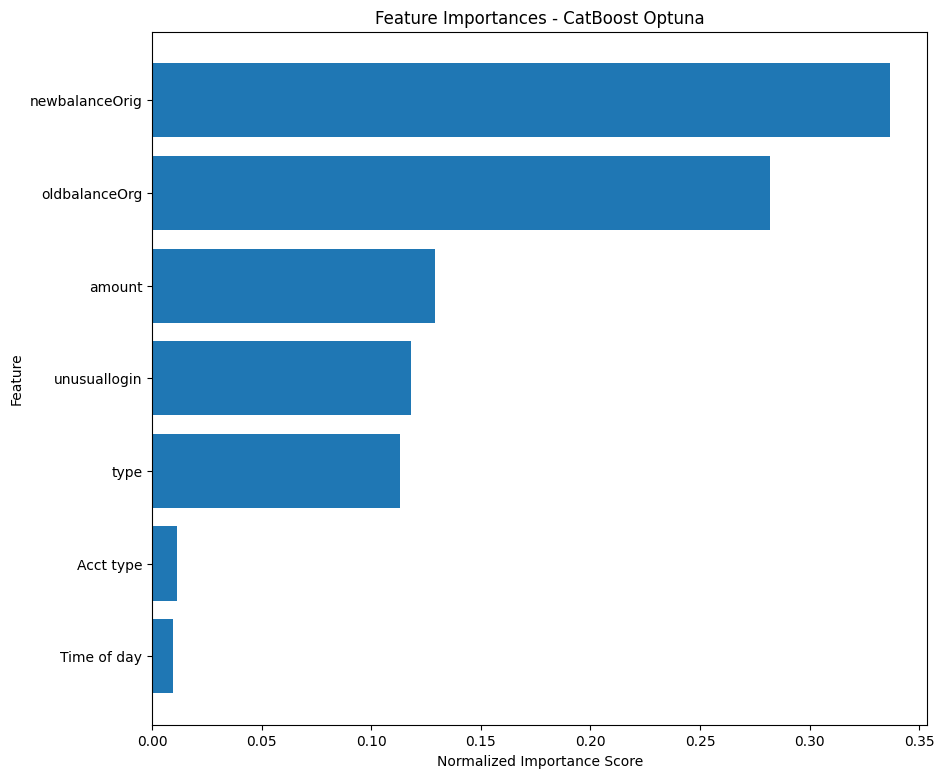

In [37]:
import matplotlib.pyplot as plt

importances = best_tree_model.feature_importances_
importances = importances / importances.sum()

importance_df = pd.DataFrame({
        'Feature':  X_train_best.columns,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 9))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title(f"Feature Importances - {best_tree_name}")
plt.xlabel("Normalized Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()


In [38]:
importance_df


,Feature,Importance
3,newbalanceOrig,0.336843
2,oldbalanceOrg,0.281879
1,amount,0.129197
4,unusuallogin,0.118141
0,type,0.113114
5,Acct type,0.011182
6,Time of day,0.009645


In [39]:
# Extract features with importance > 1%
important_features_df = importance_df[importance_df['Importance'] > 0.01]

print("Features with Importance > 1%:")
important_features_df


Features with Importance > 1%:


,Feature,Importance
3,newbalanceOrig,0.336843
2,oldbalanceOrg,0.281879
1,amount,0.129197
4,unusuallogin,0.118141
0,type,0.113114
5,Acct type,0.011182


In [40]:
important_features_df.Feature.tolist()


['newbalanceOrig',
 'oldbalanceOrg',
 'amount',
 'unusuallogin',
 'type',
 'Acct type']

SHAP Values Summary (Selected Features)


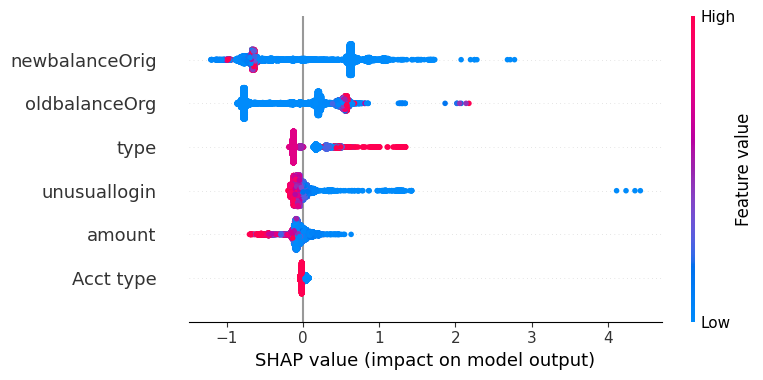

In [41]:
import shap

selected_features = important_features_df.Feature.tolist()

explainer = shap.TreeExplainer(best_tree_model)
shap_values = explainer.shap_values(X_train_best)

# Some estimators (e.g. sklearn's RandomForest) return a list/3-D array with one
# slot per class for binary classification -> keep the positive ("fraud") class
if isinstance(shap_values, list):
    shap_values = shap_values[1]
if hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

shap_df = pd.DataFrame(shap_values, columns=X_train_best.columns)
shap_selected = shap_df[selected_features]
X_selected = X_train_best[selected_features]

print("SHAP Values Summary (Selected Features)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_selected.values, X_selected, show=False)
plt.tight_layout()
plt.show()


In [42]:
# Compare mean |SHAP| against the tree feature_importances_ ranking and drop
# any feature with no meaningful SHAP impact
shap_importance = shap_selected.abs().mean().sort_values(ascending=False)
shap_importance


newbalanceOrig    0.631917
oldbalanceOrg     0.464160
type              0.205996
unusuallogin      0.112220
amount            0.108378
Acct type         0.024773
dtype: float64

In [43]:
meaningful_features = shap_importance[shap_importance > shap_importance.sum() * 0.01].index.tolist()
meaningful_features


['newbalanceOrig',
 'oldbalanceOrg',
 'type',
 'unusuallogin',
 'amount',
 'Acct type']

# 11. Rebuild the selected best model using the final set of variables

- If any variables were excluded due to low importance, perform hyperparameter optimization with Optuna on the reduced feature set.

In [44]:
new_inputs = meaningful_features
new_inputs


['newbalanceOrig',
 'oldbalanceOrg',
 'type',
 'unusuallogin',
 'amount',
 'Acct type']

In [45]:
X_train_fin = X_train_best[new_inputs]
X_test_fin = X_test_best[new_inputs]

X_test_fin.shape


(2025, 6)

In [46]:
if len(new_inputs) < X_train_best.shape[1]:
    print(f"{X_train_best.shape[1] - len(new_inputs)} variable(s) excluded -> re-tuning "
          f"{best_tree_name} on the reduced feature set with Optuna.")

    def best_params_for_model(trial):
        if 'RandomForest' in best_tree_name:
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                'max_depth': trial.suggest_int('max_depth', 3, 20),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
            }
            clf = RandomForestClassifier(random_state=42, **param)

        elif 'XGBoost' in best_tree_name:
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'gamma': trial.suggest_int('gamma', 0, 10)
            }
            clf = XGBClassifier(**param)

        elif 'LightGBM' in best_tree_name:
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
                'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'num_leaves': trial.suggest_int('num_leaves', 10, 100)
            }
            clf = LGBMClassifier(verbose=-1, **param)

        else:  # CatBoost / CatBoost_Custom
            param = {
                'iterations': trial.suggest_int('iterations', 100, 1000),
                'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
                'depth': trial.suggest_int('depth', 3, 10),
                'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
                'loss_function': trial.suggest_categorical('loss_function', ['Logloss'])
            }
            clf = CatBoostClassifier(verbose=0, **param)

        auc = cross_val_score(clf, X_train_fin, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
        return auc

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(best_params_for_model, n_trials=15)

    print('Best trial:')
    best_params = study.best_params
    print('  Value: {:.3f}'.format(study.best_value))
    print('  Params: ', best_params)

    if 'RandomForest' in best_tree_name:
        best_final_model = RandomForestClassifier(random_state=42, **best_params)
    elif 'XGBoost' in best_tree_name:
        best_final_model = XGBClassifier(**best_params)
    elif 'LightGBM' in best_tree_name:
        best_final_model = LGBMClassifier(verbose=-1, **best_params)
    else:
        best_final_model = CatBoostClassifier(verbose=0, **best_params)
else:
    print('No variables were excluded by the SHAP check -> reusing the already-tuned model.')
    best_final_model = best_tree_model


1 variable(s) excluded -> re-tuning CatBoost Optuna on the reduced feature set with Optuna.


/tmp/ipykernel_87/1329032446.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/1329032446.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),


/tmp/ipykernel_87/1329032446.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/1329032446.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),


/tmp/ipykernel_87/1329032446.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/1329032446.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),


/tmp/ipykernel_87/1329032446.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/1329032446.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),


...

/tmp/ipykernel_87/1329032446.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/1329032446.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),


/tmp/ipykernel_87/1329032446.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/1329032446.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),


/tmp/ipykernel_87/1329032446.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/1329032446.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),


/tmp/ipykernel_87/1329032446.py:38: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
/tmp/ipykernel_87/1329032446.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),


Best trial:
  Value: 0.821
  Params:  {'iterations': 967, 'learning_rate': 0.014699299854041031, 'depth': 3, 'l2_leaf_reg': 3.860272011229294, 'loss_function': 'Logloss'}


In [47]:
final_result = train_and_evaluate_model(f'{best_tree_name} final (selected features)', best_final_model, X_train_fin, y_train, X_test_fin, y_test)


Model Performance for CatBoost Optuna final (selected features)
Train Gini prob is 81.67296560053305
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8004
           1       1.00      0.31      0.48        96

    accuracy                           0.99      8100
   macro avg       1.00      0.66      0.74      8100
weighted avg       0.99      0.99      0.99      8100

[[8004    0]
 [  66   30]]
Model Performance for CatBoost Optuna final (selected features)
Test Gini prob is 52.618799074116104
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2003
           1       1.00      0.18      0.31        22

    accuracy                           0.99      2025
   macro avg       1.00      0.59      0.65      2025
weighted avg       0.99      0.99      0.99      2025

[[2003    0]
 [  18    4]]


# 12. Final Model Visuals & Summary

A closing set of professional visuals for the winning model: ROC curve, Precision-Recall curve (more informative than ROC here, since fraud is only ~1.2% of the data), a confusion matrix, and a model-comparison chart.

In [48]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

y_train_prob = best_final_model.predict_proba(X_train_fin)[:, 1]
y_test_prob = best_final_model.predict_proba(X_test_fin)[:, 1]
y_test_pred = best_final_model.predict(X_test_fin)


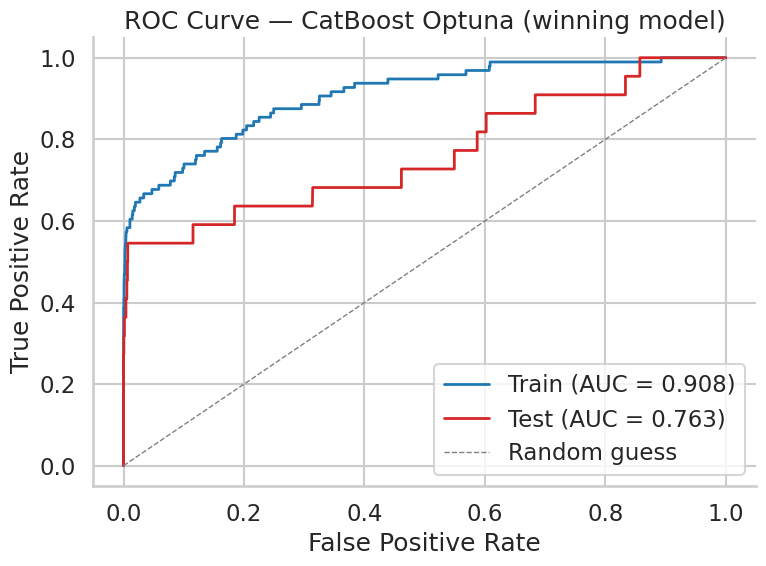

In [49]:
# ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test = auc(fpr_test, tpr_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_train, tpr_train, label=f'Train (AUC = {roc_auc_train:.3f})', color='#1f77b4', linewidth=2)
ax.plot(fpr_test, tpr_test, label=f'Test (AUC = {roc_auc_test:.3f})', color='#d62728', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve — {best_tree_name} (winning model)')
ax.legend(loc='lower right', frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig('roc_curve_final_model.png', dpi=150, bbox_inches='tight')
plt.show()


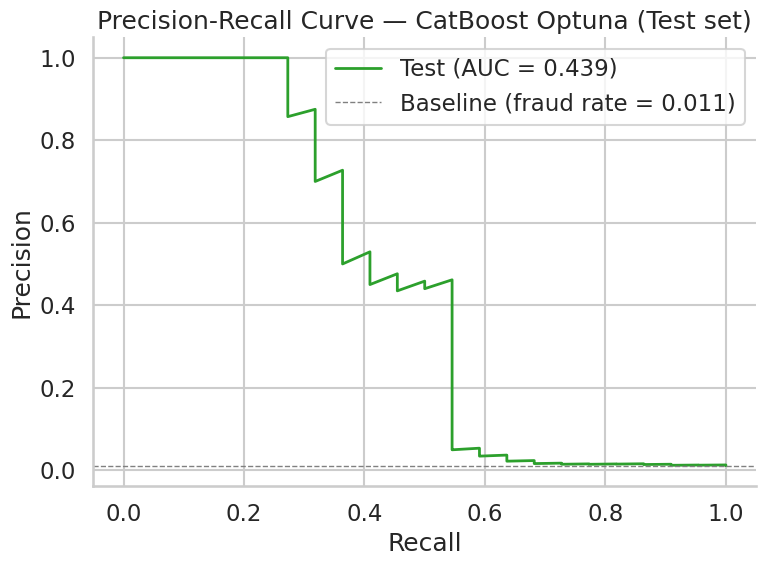

In [50]:
# Precision-Recall curve (fraud detection is a rare-event problem, so this
# matters more than ROC: it shows how precision holds up as recall increases)
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)
fraud_rate = y_test.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='#2ca02c', linewidth=2, label=f'Test (AUC = {pr_auc:.3f})')
ax.axhline(fraud_rate, linestyle='--', color='grey', linewidth=1, label=f'Baseline (fraud rate = {fraud_rate:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve — {best_tree_name} (Test set)')
ax.legend(loc='upper right', frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig('pr_curve_final_model.png', dpi=150, bbox_inches='tight')
plt.show()


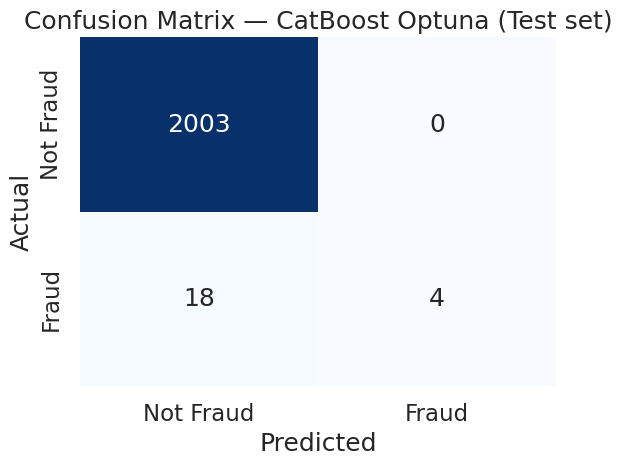

In [51]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_tree_name} (Test set)')
plt.tight_layout()
plt.savefig('confusion_matrix_final_model.png', dpi=150, bbox_inches='tight')
plt.show()


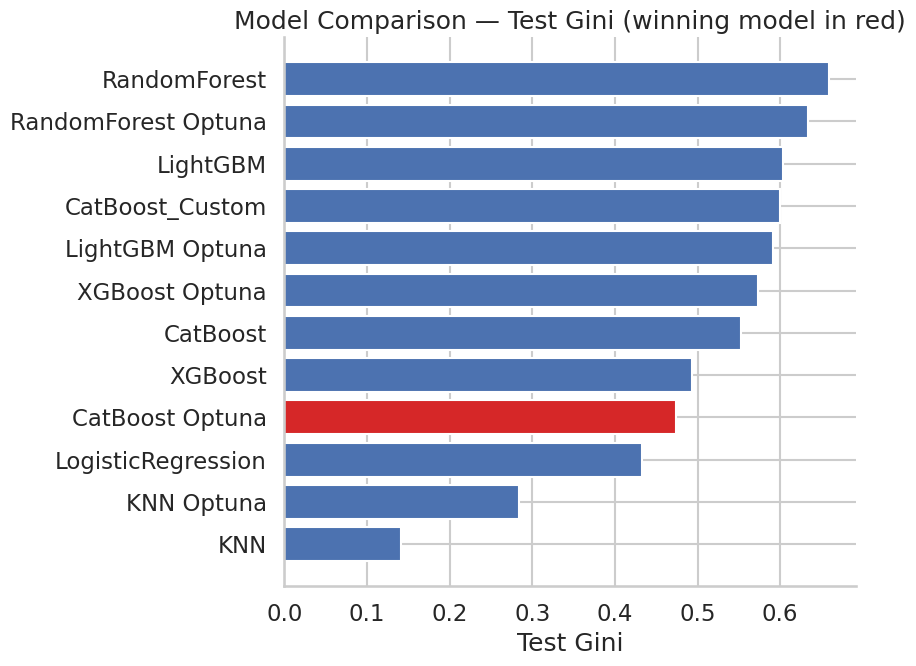

In [52]:
# Model comparison, winning model highlighted
compare_df = final_review_sorted.sort_values('Test Gini', ascending=True)
colors = ['#d62728' if m == best_tree_name else '#4c72b0' for m in compare_df['Model']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(compare_df['Model'], compare_df['Test Gini'], color=colors)
ax.set_xlabel('Test Gini')
ax.set_title('Model Comparison — Test Gini (winning model in red)')
sns.despine()
plt.tight_layout()
plt.savefig('model_comparison_test_gini.png', dpi=150, bbox_inches='tight')
plt.show()


In [53]:
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)
print(f"Winning model   : {best_tree_name} (final, selected features)")
print(f"Features used   : {new_inputs}")
print(f"Train Gini      : {final_result[0] * 100:.2f}%")
print(f"Test Gini       : {final_result[1] * 100:.2f}%")
print(f"Test ROC-AUC    : {roc_auc_test:.3f}")
print(f"Test PR-AUC     : {pr_auc:.3f}")
print("=" * 60)


FINAL MODEL SUMMARY
Winning model   : CatBoost Optuna (final, selected features)
Features used   : ['newbalanceOrig', 'oldbalanceOrg', 'type', 'unusuallogin', 'amount', 'Acct type']
Train Gini      : 81.67%
Test Gini       : 52.62%
Test ROC-AUC    : 0.763
Test PR-AUC     : 0.439
